In [2]:
import os
import torch

device = "cpu"
dtype = torch.float32

logical_cores = os.cpu_count()
physical_estimate = 14

os.environ["OMP_NUM_THREADS"] = str(physical_estimate)
os.environ["MKL_NUM_THREADS"] = str(physical_estimate)

torch.set_num_threads(physical_estimate)

print("Logical cores:", logical_cores)
print("Torch threads:", torch.get_num_threads())

Logical cores: 20
Torch threads: 14


In [3]:
from diffusers import StableDiffusionXLPipeline
from IPython.display import display
from PIL import Image

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [4]:
model_id = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    use_safetensors=True,
    safety_checker=None,
    requires_safety_checker=False,
).to(device)

Keyword arguments {'safety_checker': None, 'requires_safety_checker': False} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [32]:
WIDTH, HEIGHT = 512, 512
STEPS = 18
GUIDANCE = 5.5

In [41]:
IDENTITY = (
    "8 year old girl, child proportions, short straight medium-brown bob haircut, "
    "bright yellow knee-length raincoat, "
    "light blue t-shirt, denim shorts mid-thigh, "
    "bare legs visible, gray ankle socks, blue rain boots"
)
STYLE = (
    "photorealistic cinematic photography, natural lighting, realistic textures, "
    "realistic skin, realistic fabric detail, shallow depth of field"
)

In [42]:
scene_prompts = [

    f"wide countryside landscape, back view walking through tall grass, daylight, "
    f"{IDENTITY}, {STYLE}",

    f"open grassy field, kneeling to examine a small white wildflower, side-back view, "
    f"{IDENTITY}, {STYLE}",

    f"sunset field, medium shot looking down at wildflower, face hidden, "
    f"{IDENTITY}, {STYLE}",

    f"wide sunset landscape, side silhouette walking in grass, flower tucked into coat pocket, "
    f"{IDENTITY}, {STYLE}"
]

In [43]:
NEGATIVE = "adult, teen, dress, skirt, leggings, pants, different outfit, heels, studio, backdrop, text, watermark, illustration, cartoon, anime, flat shading"

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic fabric detail, shallow depth of field']


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic fabric detail, shallow depth of field']


Generating scene 1...


  0%|          | 0/18 [00:00<?, ?it/s]

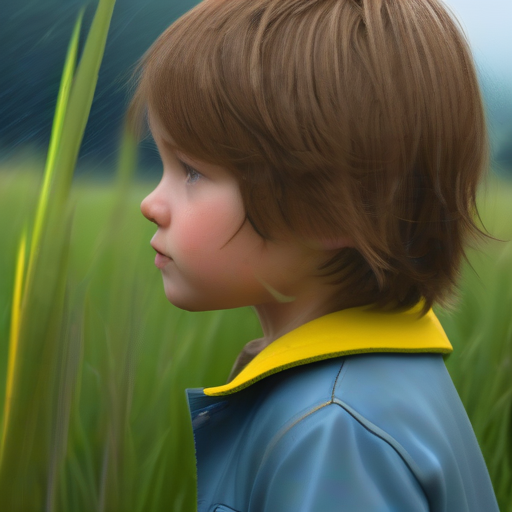

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['textures, realistic skin, realistic fabric detail, shallow depth of field']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['textures, realistic skin, realistic fabric detail, shallow depth of field']


Generating scene 2...


  0%|          | 0/18 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [44]:
generated_images = []

for i, p in enumerate(scene_prompts, 1):
    print(f"Generating scene {i}...")

    img = pipe(
        prompt=p,
        negative_prompt=NEGATIVE,
        width=WIDTH,
        height=HEIGHT,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=torch.Generator(device=device).manual_seed(3000 + i),
    ).images[0]

    generated_images.append(img)
    display(img)